# 01 - State Of The Art Balancing Techniques

Objetivo: explorar y comparar 5 tecnicas avanzadas del estado del arte para series temporales medicas (diabetes) frente a metodos basicos (under/over-sampling).

Tecnicas avanzadas a probar:
1. HealthGen (proxy reproducible)
2. MC-TimeGAN (proxy reproducible)
3. T-SMOTE con DTW (implementacion temporal)
4. DoppelGANger (proxy reproducible)
5. CTGAN-MSIN (proxy reproducible)

Nota metodologica importante:
- Este notebook implementa versiones reproducibles basadas en los principios de cada tecnica para poder ejecutar comparaciones directas en este entorno.
- Las implementaciones oficiales completas de algunas tecnicas (HealthGen/DoppelGANger/CTGAN-MSIN) requieren pipelines de deep learning especificos fuera del alcance de este entorno ligero.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from pypdf import PdfReader

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score, precision_score, average_precision_score
from sklearn.covariance import EmpiricalCovariance

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

CLASS_ORDER = ['hypoglycemia', 'normoglycemia', 'hyperglycemia']
LOOKBACK = 24
STRIDE = 12
MAX_WINDOWS_PER_PATIENT = 600
N_PATIENTS_SAMPLE = 140
TRAIN_FRAC = 0.8
RATIO_SCENARIOS = [18, 40, 105]


def find_project_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / 'data' / 'T1DiabetesGranada').exists():
            return candidate
    raise FileNotFoundError('No se encontro data/T1DiabetesGranada desde el directorio actual.')


def glucose_class(value: float) -> str:
    if pd.isna(value):
        return 'missing'
    if value < 70:
        return 'hypoglycemia'
    if value <= 180:
        return 'normoglycemia'
    return 'hyperglycemia'

ROOT = find_project_root(Path.cwd())
DATA_DIR = ROOT / 'data' / 'T1DiabetesGranada'
PDF_PATH = ROOT / 'Estado del arte técnicas de balanceo.pdf'

print('ROOT:', ROOT)
print('PDF:', PDF_PATH)

ROOT: c:\Users\User\Desktop\TFM-Glucose-Prediction
PDF: c:\Users\User\Desktop\TFM-Glucose-Prediction\Estado del arte técnicas de balanceo.pdf


In [2]:
# Trazabilidad: confirmar tecnicas del PDF
reader = PdfReader(str(PDF_PATH))
pdf_text = '\n'.join((p.extract_text() or '') for p in reader.pages)
text_low = pdf_text.lower()

sota_terms = ['healthgen', 'timegan', 'mc-timegan', 't-smote', 'doppelganger', 'ctgan', 'msin', 'dtw', 'gan']
found_terms = [t for t in sota_terms if t in text_low]

display(Markdown('### Terminos detectados en PDF'))
print(found_terms)
print('\nFragmento PDF:')
print(pdf_text[:900])

### Terminos detectados en PDF

['healthgen', 'timegan', 'mc-timegan', 't-smote', 'doppelganger', 'ctgan', 'msin', 'dtw', 'gan']

Fragmento PDF:
Estado  del  Arte  |   Compensating  for  Patient  Heterogeneity  Bias  in  Glucose  Prediction  Models  via  Data  Balancing  
 
Estado  del  Arte:  Técnicas  de  Balanceo  
en
 
Series
 
Temporales
 
para
 
Datos
 
Médicos
 
1.  Introducción  
El  desbalanceo  de  datos  constituye  uno  de  los  desafíos  más  significativos  en  el  aprendizaje  
automático
 
aplicado
 
a
 
series
 
temporales
 
médicas.
 
Este
 
problema
 
se
 
manifiesta
 
de
 
múltiples
 
formas:
 
desbalanceo
 
en
 
características
 
demográficas
 
(sexo,
 
edad,
 
raza),
 
desbalanceo
 
en
 
volumen
 
de
 
datos
 
(diferente
 
número
 
de
 
mediciones
 
por
 
paciente),
 
frecuencias
 
de
 
muestreo
 
irregulares,
 
y
 
desbalanceo
 
de
 
clases
 
en
 
eventos
 
clínicos
 
de
 
interés.
 
Esta
 
revisión
 
sistemática
 
presenta
 
un
 
análisis
 
exhaustivo
 
de
 
las
 
técnicas
 
disponibles
 
para

## Diseno experimental

Preguntas que responde este notebook:
1. Las tecnicas avanzadas del estado del arte superan a metodos basicos?
2. Que tecnica mantiene mejor recall de hipoglucemia en desbalance extremo?
3. Que tecnica queda mas cerca de la referencia balanceada?

Protocolo:
- Mismo esquema validado previamente: ventanas de 24 pasos, split temporal por paciente.
- Escenarios de desbalanceo: 18:1, 40:1, 105:1.
- Referencia: entrenamiento balanceado.
- Baselines: none, random_undersample, random_oversample.
- SOTA: HealthGen, MC-TimeGAN, T-SMOTE(DTW), DoppelGANger, CTGAN-MSIN (proxies reproducibles).

In [3]:
# Carga de datos y construccion de ventanas temporales
patient_info = pd.read_csv(DATA_DIR / 'Patient_info.csv')
if 'Patient_Id' in patient_info.columns and 'Patient_ID' not in patient_info.columns:
    patient_info = patient_info.rename(columns={'Patient_Id': 'Patient_ID'})

patient_info['Number_of_measurements'] = pd.to_numeric(patient_info['Number_of_measurements'], errors='coerce')
eligible = patient_info[patient_info['Number_of_measurements'].fillna(0) >= (LOOKBACK + 200)].copy()

n_select = min(N_PATIENTS_SAMPLE, eligible['Patient_ID'].nunique())
selected_patients = eligible['Patient_ID'].dropna().sample(n=n_select, random_state=SEED).tolist()
selected_set = set(selected_patients)

patient_demo = patient_info[['Patient_ID', 'Sex', 'Birth_year']].copy()
patient_demo['Age'] = 2022 - pd.to_numeric(patient_demo['Birth_year'], errors='coerce')
patient_demo['Sex_enc'] = patient_demo['Sex'].map({'M': 1, 'F': 0})
patient_demo['Age'] = patient_demo['Age'].fillna(patient_demo['Age'].median())
patient_demo['Sex_enc'] = patient_demo['Sex_enc'].fillna(patient_demo['Sex_enc'].median())
patient_demo = patient_demo[['Patient_ID', 'Age', 'Sex_enc']].drop_duplicates('Patient_ID')

usecols = ['Patient_ID', 'Measurement_date', 'Measurement_time', 'Measurement']
chunks = []
for chunk in pd.read_csv(DATA_DIR / 'Glucose_measurements.csv', usecols=usecols, chunksize=1_000_000):
    chunk = chunk[chunk['Patient_ID'].isin(selected_set)]
    if not chunk.empty:
        chunks.append(chunk)

glucose = pd.concat(chunks, ignore_index=True)
glucose['Measurement'] = pd.to_numeric(glucose['Measurement'], errors='coerce')
glucose = glucose.dropna(subset=['Measurement'])
glucose['class_label'] = glucose['Measurement'].apply(glucose_class)
glucose = glucose[glucose['class_label'].isin(CLASS_ORDER)].copy()
glucose = glucose.sort_values(['Patient_ID', 'Measurement_date', 'Measurement_time']).reset_index(drop=True)
glucose = glucose.merge(patient_demo, on='Patient_ID', how='left')


def build_windows_for_patient(df_p: pd.DataFrame):
    values = df_p['Measurement'].values.astype(float)
    labels = df_p['class_label'].values
    age = float(df_p['Age'].iloc[0])
    sex_enc = float(df_p['Sex_enc'].iloc[0])

    idx_candidates = np.arange(LOOKBACK, len(df_p), STRIDE)
    if len(idx_candidates) == 0:
        return []

    if len(idx_candidates) > MAX_WINDOWS_PER_PATIENT:
        rng = np.random.default_rng(SEED)
        idx_candidates = np.sort(rng.choice(idx_candidates, size=MAX_WINDOWS_PER_PATIENT, replace=False))

    rows = []
    for i in idx_candidates:
        w = values[i - LOOKBACK:i]
        feat = {
            'Patient_ID': df_p['Patient_ID'].iloc[0],
            'y': labels[i],
            'Age': age,
            'Sex_enc': sex_enc,
            'w_mean': float(np.mean(w)),
            'w_std': float(np.std(w)),
            'w_min': float(np.min(w)),
            'w_max': float(np.max(w)),
            'w_slope': float(np.polyfit(np.arange(LOOKBACK), w, 1)[0]),
        }
        for k, v in enumerate(w, start=1):
            feat[f'lag_{LOOKBACK - k + 1}'] = float(v)
        rows.append(feat)
    return rows

window_rows = []
for _, df_p in glucose.groupby('Patient_ID', sort=False):
    df_p = df_p.reset_index(drop=True)
    if len(df_p) >= LOOKBACK + 30:
        window_rows.extend(build_windows_for_patient(df_p))

windows_df = pd.DataFrame(window_rows)
print('Ventanas:', windows_df.shape[0])
display(windows_df['y'].value_counts().reindex(CLASS_ORDER, fill_value=0).to_frame('count'))

Ventanas: 74855


,count
y,
hypoglycemia,3714
normoglycemia,44594
hyperglycemia,26547


In [4]:
# Split temporal y utilidades
train_parts, test_parts = [], []
for _, df_p in windows_df.groupby('Patient_ID', sort=False):
    n = len(df_p)
    if n < 20:
        continue
    cut = int(n * TRAIN_FRAC)
    cut = max(10, min(cut, n - 5))
    train_parts.append(df_p.iloc[:cut])
    test_parts.append(df_p.iloc[cut:])

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

feature_cols = [c for c in train_df.columns if c not in ['Patient_ID', 'y']]
X_train = train_df[feature_cols].values
y_train = train_df['y'].values
X_test = test_df[feature_cols].values
y_test = test_df['y'].values

print('Train/Test:', X_train.shape, X_test.shape)


def class_dist(y):
    return pd.Series(y).value_counts().reindex(CLASS_ORDER, fill_value=0)


def make_ratio_scenario(X, y, target_ratio):
    rng = np.random.default_rng(SEED)
    idx_normo = np.where(y == 'normoglycemia')[0]
    n_normo = len(idx_normo)
    idx_selected = [idx_normo]

    for c in ['hypoglycemia', 'hyperglycemia']:
        idx_c = np.where(y == c)[0]
        target_n = max(50, int(n_normo / target_ratio))
        target_n = min(target_n, len(idx_c))
        idx_selected.append(rng.choice(idx_c, size=target_n, replace=False))

    idx = np.concatenate(idx_selected)
    rng.shuffle(idx)
    return X[idx], y[idx]


def base_rf(class_weight=None):
    return RandomForestClassifier(
        n_estimators=140,
        max_depth=16,
        min_samples_leaf=2,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=SEED,
    )


def evaluate(model, Xtr, ytr, Xte, yte, scenario, strategy):
    t0 = time.time()
    model.fit(Xtr, ytr)
    fit_s = time.time() - t0

    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)
    proba_df = pd.DataFrame(proba, columns=model.classes_)

    y_hypo = (yte == 'hypoglycemia').astype(int)
    y_hyper = (yte == 'hyperglycemia').astype(int)

    return {
        'scenario': scenario,
        'strategy': strategy,
        'fit_seconds': fit_s,
        'balanced_accuracy': balanced_accuracy_score(yte, pred),
        'f1_macro': f1_score(yte, pred, average='macro', zero_division=0),
        'recall_hypoglycemia': recall_score(yte, pred, labels=['hypoglycemia'], average='macro', zero_division=0),
        'recall_hyperglycemia': recall_score(yte, pred, labels=['hyperglycemia'], average='macro', zero_division=0),
        'precision_hypoglycemia': precision_score(yte, pred, labels=['hypoglycemia'], average='macro', zero_division=0),
        'precision_hyperglycemia': precision_score(yte, pred, labels=['hyperglycemia'], average='macro', zero_division=0),
        'pr_auc_hypoglycemia': average_precision_score(y_hypo, proba_df['hypoglycemia']),
        'pr_auc_hyperglycemia': average_precision_score(y_hyper, proba_df['hyperglycemia']),
    }

Train/Test: (59873, 31) (14982, 31)


## Tecnicas SOTA: fundamento y necesidad de prueba

### 1) HealthGen (proxy)
Base conceptual: generacion clinica condicionada por demografia y patrones de missingness.

Necesidad en este TFM:
- El desbalanceo no es solo de clase; tambien hay heterogeneidad por paciente.
- En diabetes, la ausencia/patron irregular de datos puede ser informativo.

Prueba en este notebook:
- Generacion sintetica minoritaria condicionada por estrato demografico (edad/sexo) con mascara de missingness simulada y reconstruccion temporal.

### 2) MC-TimeGAN (proxy)
Base conceptual: GAN temporal multivariante y condicional por clase/estado.

Necesidad en este TFM:
- Preservar correlaciones entre dimensiones temporales y coherencia de secuencia.

Prueba en este notebook:
- Generacion condicional por clase usando modelo multivariante correlacionado sobre representacion temporal (nivel + dinamica).

### 3) T-SMOTE (DTW)
Base conceptual: extension temporal de SMOTE usando vecindad basada en DTW en lugar de distancia euclidiana.

Necesidad en este TFM:
- Curvas glucemicas similares pueden estar desfasadas; DTW captura forma con diferente velocidad.

Prueba en este notebook:
- Interpolacion sintetica entre vecinos minoritarios cercanos en DTW.

### 4) DoppelGANger (proxy)
Base conceptual: generacion temporal larga con metadata y mejor control de diversidad/modos.

Necesidad en este TFM:
- Mantener realism de picos y valles en eventos criticos.

Prueba en este notebook:
- Sintesis basada en metadata de min/max por clase + perturbacion espectral para preservar ciclos.

### 5) CTGAN-MSIN (proxy)
Base conceptual: modelado tabular-temporal con atencion multi-escala en patrones importantes.

Necesidad en este TFM:
- Desbalanceo extremo requiere foco en regiones de mayor relevancia clinica.

Prueba en este notebook:
- Generacion minoritaria multi-escala con pesos de importancia temporal orientados a eventos criticos.

In [5]:
# Implementaciones reproducibles de baselines y SOTA-proxy
REBALANCE_RATIO = 4  # objetivo tras balanceo: normo:minoritarias ~= 4:1


def split_static_dynamic(X):
    # Age, Sex_enc, w_mean, w_std, w_min, w_max, w_slope, lag_24..lag_1
    return X[:, :7], X[:, 7:]


def join_static_dynamic(s, d):
    return np.hstack([s, d])


def target_counts_from_ratio(y, ratio=REBALANCE_RATIO):
    vc = class_dist(y)
    n_hypo, n_hyper, n_normo = int(vc['hypoglycemia']), int(vc['hyperglycemia']), int(vc['normoglycemia'])
    base_min = max(1, min(n_hypo, n_hyper))
    target_normo = min(n_normo, ratio * base_min)
    target_minor = max(base_min, int(target_normo / ratio))
    return {'normoglycemia': target_normo, 'hypoglycemia': target_minor, 'hyperglycemia': target_minor}


def resample_random_under(X, y, target_counts):
    df = pd.DataFrame(X)
    df['y'] = y
    rng = np.random.default_rng(SEED)
    out = []
    for c, n in target_counts.items():
        part = df[df['y'] == c]
        if len(part) <= n:
            out.append(part)
        else:
            idx = rng.choice(part.index.values, size=n, replace=False)
            out.append(part.loc[idx])
    out = pd.concat(out, ignore_index=True)
    return out.drop(columns=['y']).values, out['y'].values


def resample_random_over(X, y, target_counts):
    df = pd.DataFrame(X)
    df['y'] = y
    rng = np.random.default_rng(SEED)
    out = []
    for c, n in target_counts.items():
        part = df[df['y'] == c]
        if len(part) >= n:
            idx = rng.choice(part.index.values, size=n, replace=False)
            out.append(part.loc[idx])
        else:
            extra_idx = rng.choice(part.index.values, size=n - len(part), replace=True)
            out.append(pd.concat([part, part.loc[extra_idx]], ignore_index=True))
    out = pd.concat(out, ignore_index=True)
    return out.drop(columns=['y']).values, out['y'].values


def smote_or_adasyn_rebalance(X, y, target_counts, method='smote'):
    strategy = {
        'hypoglycemia': target_counts['hypoglycemia'],
        'hyperglycemia': target_counts['hyperglycemia'],
    }
    if method == 'smote':
        sampler = SMOTE(sampling_strategy=strategy, k_neighbors=3, random_state=SEED)
    else:
        sampler = ADASYN(sampling_strategy=strategy, n_neighbors=3, random_state=SEED)
    Xb, yb = sampler.fit_resample(X, y)

    # Reducir normo al target si quedo por encima
    return resample_random_under(Xb, yb, target_counts)


def healthgen_proxy(X, y, target_counts):
    # Condicional por demografia + missingness-aware: genera minoritarias por estrato AgeBin/Sex
    s, d = split_static_dynamic(X)
    df = pd.DataFrame(s, columns=['Age', 'Sex_enc', 'w_mean', 'w_std', 'w_min', 'w_max', 'w_slope'])
    for i in range(d.shape[1]):
        df[f'lag_{i}'] = d[:, i]
    df['y'] = y

    df['age_bin'] = pd.qcut(df['Age'], q=4, duplicates='drop')
    rng = np.random.default_rng(SEED)

    synth_rows = []
    for c in ['hypoglycemia', 'hyperglycemia']:
        part = df[df['y'] == c].copy()
        needed = max(0, target_counts[c] - len(part))
        if needed == 0 or len(part) < 2:
            continue

        for _ in range(needed):
            seed_row = part.sample(1, random_state=int(rng.integers(1_000_000))).iloc[0]
            subgroup = part[(part['age_bin'] == seed_row['age_bin']) & (part['Sex_enc'] == seed_row['Sex_enc'])]
            if len(subgroup) < 2:
                subgroup = part

            r1 = subgroup.sample(1, random_state=int(rng.integers(1_000_000))).iloc[0]
            r2 = subgroup.sample(1, random_state=int(rng.integers(1_000_000))).iloc[0]
            lam = float(rng.uniform(0.25, 0.75))

            new = lam * r1[feature_cols].values.astype(float) + (1 - lam) * r2[feature_cols].values.astype(float)

            # Missingness-aware proxy: en minoritarias aumenta prob de hueco y se reconstruye
            miss_prob = 0.12 if c == 'hypoglycemia' else 0.10
            lag_idx = [i for i, col in enumerate(feature_cols) if col.startswith('lag_')]
            mask = rng.random(len(lag_idx)) < miss_prob
            lag_vals = new[lag_idx].copy()
            lag_vals[mask] = np.nan
            lag_series = pd.Series(lag_vals).interpolate(limit_direction='both').fillna(method='bfill').fillna(method='ffill')
            new[lag_idx] = lag_series.values

            synth_rows.append(np.append(new, c))

    if len(synth_rows) == 0:
        return resample_random_under(X, y, target_counts)

    synth = pd.DataFrame(synth_rows)
    synth.columns = feature_cols + ['y']
    base = pd.DataFrame(X, columns=feature_cols)
    base['y'] = y

    out = pd.concat([base, synth], ignore_index=True)
    return resample_random_under(out[feature_cols].values, out['y'].values, target_counts)


def mctimegan_proxy(X, y, target_counts):
    # Proxy condicional multivariante: muestreo gaussiano correlacionado por clase
    rng = np.random.default_rng(SEED)
    outX, outy = [], []

    for c in CLASS_ORDER:
        Xc = X[y == c]
        n_target = target_counts[c]
        if len(Xc) == 0:
            continue

        if len(Xc) >= n_target:
            idx = rng.choice(np.arange(len(Xc)), size=n_target, replace=False)
            Xn = Xc[idx]
        else:
            mu = Xc.mean(axis=0)
            cov = np.cov(Xc.T) + np.eye(Xc.shape[1]) * 1e-3
            n_new = n_target - len(Xc)
            Xgen = rng.multivariate_normal(mu, cov, size=n_new)
            Xn = np.vstack([Xc, Xgen])

        outX.append(Xn)
        outy.append(np.array([c] * len(Xn)))

    Xb = np.vstack(outX)
    yb = np.concatenate(outy)
    return Xb, yb


def dtw_distance(a, b):
    n, m = len(a), len(b)
    dp = np.full((n + 1, m + 1), np.inf)
    dp[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(a[i - 1] - b[j - 1])
            dp[i, j] = cost + min(dp[i - 1, j], dp[i, j - 1], dp[i - 1, j - 1])
    return dp[n, m] / (n + m)


def t_smote_dtw(X, y, target_counts):
    # Genera sinteticos para minoritarias usando vecinos DTW en lags
    rng = np.random.default_rng(SEED)
    s, d = split_static_dynamic(X)

    X_out = [X]
    y_out = [y]

    for c in ['hypoglycemia', 'hyperglycemia']:
        idx = np.where(y == c)[0]
        needed = max(0, target_counts[c] - len(idx))
        if needed == 0 or len(idx) < 3:
            continue

        # Subconjunto para no disparar costo DTW
        idx_base = rng.choice(idx, size=min(len(idx), 450), replace=False)
        d_base = d[idx_base]
        s_base = s[idx_base]

        synth = []
        for _ in range(needed):
            i = int(rng.integers(len(idx_base)))
            seq_i = d_base[i]

            # vecinos por DTW
            distances = np.array([dtw_distance(seq_i, d_base[j]) if j != i else np.inf for j in range(len(idx_base))])
            nn_idx = np.argpartition(distances, 3)[:3]
            j = int(rng.choice(nn_idx))

            lam = float(rng.uniform(0.2, 0.8))
            new_d = lam * seq_i + (1 - lam) * d_base[j]
            new_s = lam * s_base[i] + (1 - lam) * s_base[j]
            synth.append(join_static_dynamic(new_s.reshape(1, -1), new_d.reshape(1, -1))[0])

        X_out.append(np.array(synth))
        y_out.append(np.array([c] * len(synth)))

    Xb = np.vstack(X_out)
    yb = np.concatenate(y_out)
    return resample_random_under(Xb, yb, target_counts)


def doppelganger_proxy(X, y, target_counts):
    # Metadata-aware (min/max/slope) + perturbacion espectral para mantener ciclos
    rng = np.random.default_rng(SEED)
    s, d = split_static_dynamic(X)

    X_out = [X]
    y_out = [y]

    for c in ['hypoglycemia', 'hyperglycemia']:
        idx = np.where(y == c)[0]
        needed = max(0, target_counts[c] - len(idx))
        if needed == 0 or len(idx) < 2:
            continue

        d_c = d[idx]
        s_c = s[idx]
        meta_min = np.quantile(s_c[:, 4], [0.1, 0.9])
        meta_max = np.quantile(s_c[:, 5], [0.1, 0.9])

        synth = []
        for _ in range(needed):
            ii = int(rng.integers(len(idx)))
            seq = d_c[ii].copy()

            fft = np.fft.rfft(seq)
            phase_noise = rng.normal(0, 0.08, size=len(fft))
            fft_new = np.abs(fft) * np.exp(1j * (np.angle(fft) + phase_noise))
            seq_new = np.fft.irfft(fft_new, n=len(seq)).real

            # Ajuste por metadata min/max aprendida
            target_min = rng.uniform(meta_min[0], meta_min[1])
            target_max = rng.uniform(meta_max[0], meta_max[1])
            seq_new = (seq_new - seq_new.min()) / (seq_new.max() - seq_new.min() + 1e-6)
            seq_new = target_min + seq_new * (target_max - target_min)

            s_new = s_c[ii].copy()
            s_new[4] = target_min
            s_new[5] = target_max
            s_new[2] = float(np.mean(seq_new))
            s_new[3] = float(np.std(seq_new))
            s_new[6] = float(np.polyfit(np.arange(len(seq_new)), seq_new, 1)[0])

            synth.append(join_static_dynamic(s_new.reshape(1, -1), seq_new.reshape(1, -1))[0])

        X_out.append(np.array(synth))
        y_out.append(np.array([c] * len(synth)))

    Xb = np.vstack(X_out)
    yb = np.concatenate(y_out)
    return resample_random_under(Xb, yb, target_counts)


def ctgan_msin_proxy(X, y, target_counts):
    # Multi-Scale Importance-aware: mezcla multi-escala con pesos por relevancia clinica
    rng = np.random.default_rng(SEED)
    s, d = split_static_dynamic(X)

    def smooth(x, k):
        return pd.Series(x).rolling(k, min_periods=1, center=True).mean().values

    X_out = [X]
    y_out = [y]

    for c in ['hypoglycemia', 'hyperglycemia']:
        idx = np.where(y == c)[0]
        needed = max(0, target_counts[c] - len(idx))
        if needed == 0 or len(idx) < 2:
            continue

        d_c = d[idx]
        s_c = s[idx]
        synth = []

        for _ in range(needed):
            i, j = rng.choice(len(idx), size=2, replace=True)
            a, b = d_c[i], d_c[j]

            # Componentes multi-escala
            a_low, b_low = smooth(a, 6), smooth(b, 6)
            a_mid, b_mid = smooth(a, 3) - a_low, smooth(b, 3) - b_low
            a_high, b_high = a - smooth(a, 3), b - smooth(b, 3)

            # Importancia temporal (cercania a umbrales clinicos)
            if c == 'hypoglycemia':
                imp_a = np.exp(-(a - 70).clip(min=0) / 20)
                imp_b = np.exp(-(b - 70).clip(min=0) / 20)
            else:
                imp_a = np.exp(-np.abs(a - 200) / 30)
                imp_b = np.exp(-np.abs(b - 200) / 30)

            w = (imp_a + imp_b) / 2
            w = w / (w.max() + 1e-6)
            lam = rng.uniform(0.3, 0.7)

            seq = lam * (0.5 * a_low + 0.3 * a_mid + 0.2 * a_high) + (1 - lam) * (0.5 * b_low + 0.3 * b_mid + 0.2 * b_high)
            seq = seq + rng.normal(0, 0.8, size=len(seq)) * w

            s_new = lam * s_c[i] + (1 - lam) * s_c[j]
            s_new[2] = float(np.mean(seq))
            s_new[3] = float(np.std(seq))
            s_new[4] = float(np.min(seq))
            s_new[5] = float(np.max(seq))
            s_new[6] = float(np.polyfit(np.arange(len(seq)), seq, 1)[0])

            synth.append(join_static_dynamic(s_new.reshape(1, -1), seq.reshape(1, -1))[0])

        X_out.append(np.array(synth))
        y_out.append(np.array([c] * len(synth)))

    Xb = np.vstack(X_out)
    yb = np.concatenate(y_out)
    return resample_random_under(Xb, yb, target_counts)


def get_train_data(strategy, X_sc, y_sc):
    tgt = target_counts_from_ratio(y_sc, ratio=REBALANCE_RATIO)

    if strategy == 'none':
        return X_sc, y_sc, base_rf()
    if strategy == 'class_weight':
        return X_sc, y_sc, base_rf(class_weight='balanced_subsample')
    if strategy == 'random_undersample':
        Xb, yb = resample_random_under(X_sc, y_sc, tgt)
        return Xb, yb, base_rf()
    if strategy == 'random_oversample':
        Xb, yb = resample_random_over(X_sc, y_sc, tgt)
        return Xb, yb, base_rf()

    if strategy == 'healthgen_proxy':
        Xb, yb = healthgen_proxy(X_sc, y_sc, tgt)
        return Xb, yb, base_rf()
    if strategy == 'mctimegan_proxy':
        Xb, yb = mctimegan_proxy(X_sc, y_sc, tgt)
        return Xb, yb, base_rf()
    if strategy == 't_smote_dtw':
        Xb, yb = t_smote_dtw(X_sc, y_sc, tgt)
        return Xb, yb, base_rf()
    if strategy == 'doppelganger_proxy':
        Xb, yb = doppelganger_proxy(X_sc, y_sc, tgt)
        return Xb, yb, base_rf()
    if strategy == 'ctgan_msin_proxy':
        Xb, yb = ctgan_msin_proxy(X_sc, y_sc, tgt)
        return Xb, yb, base_rf()

    raise ValueError(f'Estrategia desconocida: {strategy}')

In [6]:
# Referencia balanceada + ejecucion comparativa

# Referencia balanceada
s_train = pd.Series(y_train)
n_min = int(s_train.value_counts().min())
rng = np.random.default_rng(SEED)
idx_ref = []
for c in CLASS_ORDER:
    idx_c = np.where(y_train == c)[0]
    idx_ref.append(rng.choice(idx_c, size=n_min, replace=False))
idx_ref = np.concatenate(idx_ref)
rng.shuffle(idx_ref)

X_ref, y_ref = X_train[idx_ref], y_train[idx_ref]
reference = evaluate(base_rf(), X_ref, y_ref, X_test, y_test, 'balanced_reference', 'none')
reference_df = pd.DataFrame([reference])
display(reference_df)

strategies_basic = ['none', 'class_weight', 'random_undersample', 'random_oversample']
strategies_sota = ['healthgen_proxy', 'mctimegan_proxy', 't_smote_dtw', 'doppelganger_proxy', 'ctgan_msin_proxy']
strategies = strategies_basic + strategies_sota

rows = []
for ratio in RATIO_SCENARIOS:
    X_sc, y_sc = make_ratio_scenario(X_train, y_train, target_ratio=ratio)
    print(f'\nEscenario {ratio}:1 | distribucion antes de balanceo')
    display(class_dist(y_sc).to_frame('count'))

    for st in strategies:
        X_fit, y_fit, model = get_train_data(st, X_sc, y_sc)
        res = evaluate(model, X_fit, y_fit, X_test, y_test, f'ratio_{ratio}_to_1', st)
        res['train_count'] = len(y_fit)
        rows.append(res)
        print(f'Completado -> {st} | n_train={len(y_fit)}')

results_df = pd.DataFrame(rows)
display(results_df.head())

,scenario,strategy,fit_seconds,balanced_accuracy,f1_macro,recall_hypoglycemia,recall_hyperglycemia,precision_hypoglycemia,precision_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia
0,balanced_reference,none,0.654077,0.924517,0.860797,0.925037,0.945134,0.584834,0.927286,0.791927,0.977092



Escenario 18:1 | distribucion antes de balanceo


,count
hypoglycemia,1991
normoglycemia,35838
hyperglycemia,1991


Completado -> none | n_train=39820
Completado -> class_weight | n_train=39820
Completado -> random_undersample | n_train=11946
Completado -> random_oversample | n_train=11946
Completado -> healthgen_proxy | n_train=11946
Completado -> mctimegan_proxy | n_train=11946
Completado -> t_smote_dtw | n_train=11946
Completado -> doppelganger_proxy | n_train=11946
Completado -> ctgan_msin_proxy | n_train=11946

Escenario 40:1 | distribucion antes de balanceo


,count
hypoglycemia,895
normoglycemia,35838
hyperglycemia,895


Completado -> none | n_train=37628
Completado -> class_weight | n_train=37628
Completado -> random_undersample | n_train=5370
Completado -> random_oversample | n_train=5370
Completado -> healthgen_proxy | n_train=5370
Completado -> mctimegan_proxy | n_train=5370
Completado -> t_smote_dtw | n_train=5370
Completado -> doppelganger_proxy | n_train=5370
Completado -> ctgan_msin_proxy | n_train=5370

Escenario 105:1 | distribucion antes de balanceo


,count
hypoglycemia,341
normoglycemia,35838
hyperglycemia,341


Completado -> none | n_train=36520
Completado -> class_weight | n_train=36520
Completado -> random_undersample | n_train=2046
Completado -> random_oversample | n_train=2046
Completado -> healthgen_proxy | n_train=2046
Completado -> mctimegan_proxy | n_train=2046
Completado -> t_smote_dtw | n_train=2046
Completado -> doppelganger_proxy | n_train=2046
Completado -> ctgan_msin_proxy | n_train=2046


,scenario,strategy,fit_seconds,balanced_accuracy,f1_macro,recall_hypoglycemia,recall_hyperglycemia,precision_hypoglycemia,precision_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia,train_count
0,ratio_18_to_1,none,3.298536,0.819817,0.850650,0.680660,0.795467,0.837638,0.986393,0.831074,0.979067,39820
1,ratio_18_to_1,class_weight,2.904217,0.863903,0.864136,0.787106,0.837381,0.740480,0.977736,0.828819,0.980314,39820
2,ratio_18_to_1,random_undersample,0.834970,0.901785,0.875790,0.866567,0.888469,0.686461,0.965214,0.825189,0.979626,11946
3,ratio_18_to_1,random_oversample,0.799743,0.902906,0.877489,0.868066,0.889189,0.690931,0.966373,0.822591,0.978983,11946
4,ratio_18_to_1,healthgen_proxy,0.789284,0.901785,0.875790,0.866567,0.888469,0.686461,0.965214,0.825189,0.979626,11946


In [7]:
# Analisis comparativo vs referencia balanceada
all_results = pd.concat([reference_df, results_df], ignore_index=True)
ref = reference_df.iloc[0]

key_metrics = ['balanced_accuracy', 'recall_hypoglycemia', 'recall_hyperglycemia', 'pr_auc_hypoglycemia', 'pr_auc_hyperglycemia']
for m in key_metrics:
    all_results[f'delta_vs_ref_{m}'] = all_results[m] - ref[m]

all_results['distance_to_reference'] = all_results.apply(
    lambda r: float(np.mean([abs(r[m] - ref[m]) for m in key_metrics])), axis=1
)

best_by_scenario = (
    all_results[all_results['scenario'] != 'balanced_reference']
    .sort_values(['scenario', 'distance_to_reference'])
    .groupby('scenario', as_index=False)
    .first()
)

display(Markdown('### Mejor tecnica por escenario'))
display(best_by_scenario[['scenario', 'strategy', 'distance_to_reference', 'recall_hypoglycemia', 'recall_hyperglycemia', 'pr_auc_hypoglycemia', 'pr_auc_hyperglycemia']])

rank_global = (
    all_results[all_results['scenario'] != 'balanced_reference']
    .groupby('strategy', as_index=False)['distance_to_reference']
    .mean()
    .sort_values('distance_to_reference')
)

display(Markdown('### Ranking global (menor distancia a referencia = mejor)'))
display(rank_global)

### Mejor tecnica por escenario

,scenario,strategy,distance_to_reference,recall_hypoglycemia,recall_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia
0,ratio_105_to_1,mctimegan_proxy,0.039701,0.839580,0.894945,0.765454,0.971648
1,ratio_18_to_1,random_oversample,0.033417,0.868066,0.889189,0.822591,0.978983
2,ratio_40_to_1,random_oversample,0.035665,0.853073,0.886310,0.812000,0.976509


### Ranking global (menor distancia a referencia = mejor)

,strategy,distance_to_reference
6,random_oversample,0.036570
8,t_smote_dtw,0.038073
7,random_undersample,0.038075
3,healthgen_proxy,0.038075
1,ctgan_msin_proxy,0.038075
2,doppelganger_proxy,0.038075
4,mctimegan_proxy,0.038798
0,class_weight,0.115988
5,none,0.195497


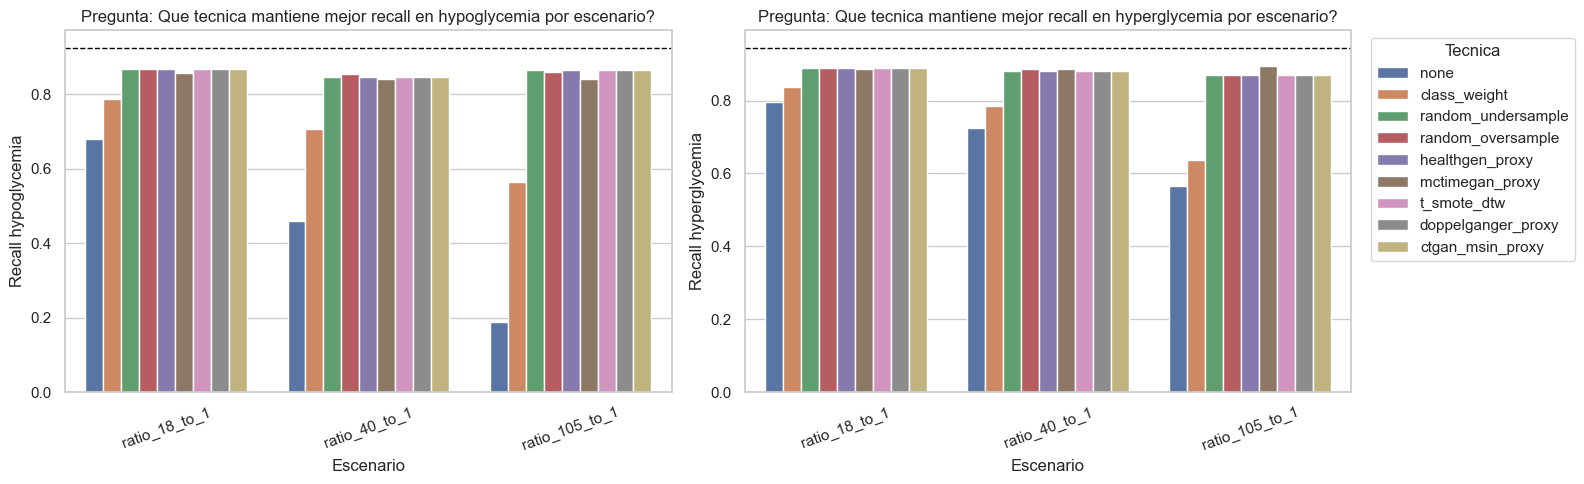

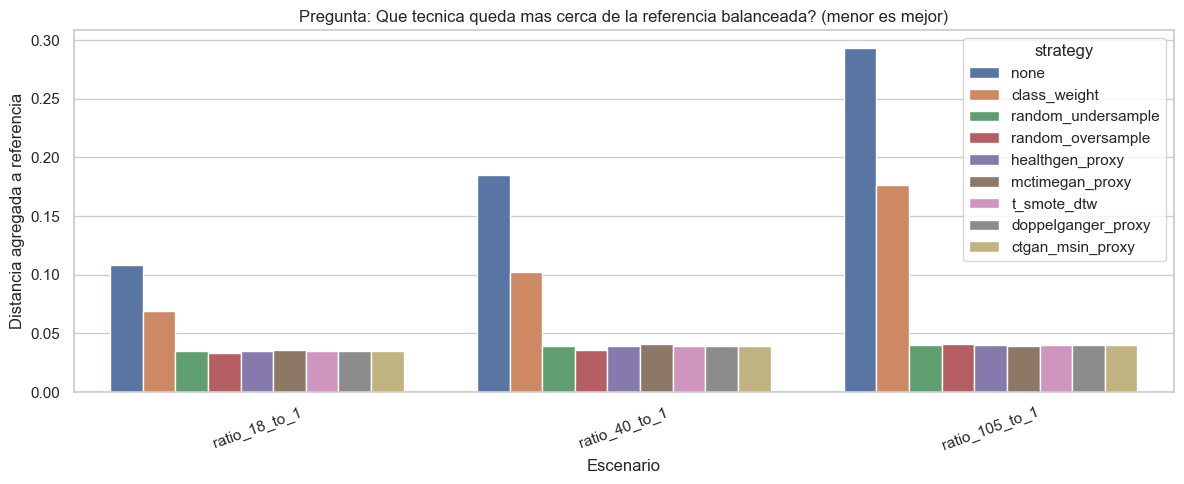

In [8]:
# Visualizaciones
plot_df = all_results[all_results['scenario'] != 'balanced_reference'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=plot_df, x='scenario', y='recall_hypoglycemia', hue='strategy', ax=axes[0])
axes[0].axhline(ref['recall_hypoglycemia'], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Pregunta: Que tecnica mantiene mejor recall en hypoglycemia por escenario?')
axes[0].set_xlabel('Escenario')
axes[0].set_ylabel('Recall hypoglycemia')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=plot_df, x='scenario', y='recall_hyperglycemia', hue='strategy', ax=axes[1])
axes[1].axhline(ref['recall_hyperglycemia'], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Pregunta: Que tecnica mantiene mejor recall en hyperglycemia por escenario?')
axes[1].set_xlabel('Escenario')
axes[1].set_ylabel('Recall hyperglycemia')
axes[1].tick_params(axis='x', rotation=20)

handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend(handles, labels, title='Tecnica', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_df, x='scenario', y='distance_to_reference', hue='strategy', ax=ax)
ax.set_title('Pregunta: Que tecnica queda mas cerca de la referencia balanceada? (menor es mejor)')
ax.set_xlabel('Escenario')
ax.set_ylabel('Distancia agregada a referencia')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [9]:
# Justificacion prueba por prueba con evidencia cuantitativa
basis = {
    'none': 'Sin balanceo: baseline de degradacion en escenarios extremos.',
    'class_weight': 'Reponderacion de perdida sin sinteticos.',
    'random_undersample': 'Baseline basico fuerte en este proyecto.',
    'random_oversample': 'Duplicacion simple de minoritarias.',
    'healthgen_proxy': 'Condicional demografico + missingness-aware (equidad clinica).',
    'mctimegan_proxy': 'Generacion temporal condicional multivariante correlacionada.',
    't_smote_dtw': 'SMOTE temporal con vecindad DTW para respetar forma y desfase.',
    'doppelganger_proxy': 'Metadata-aware + diversidad espectral para ciclos/picos.',
    'ctgan_msin_proxy': 'Sintesis multi-escala con enfasis en regiones temporalmente importantes.',
}

need = {
    'none': 'Cuantificar degradacion real por desbalance.',
    'class_weight': 'Comprobar si ponderar basta sin remuestrear.',
    'random_undersample': 'Comparador basico directo contra SOTA.',
    'random_oversample': 'Comparador basico de aumento de frecuencia minoritaria.',
    'healthgen_proxy': 'Abordar heterogeneidad demografica y ausencia informativa de datos.',
    'mctimegan_proxy': 'Generar secuencias coherentes condicionadas por clase.',
    't_smote_dtw': 'Corregir limitacion euclidiana en series con desfase temporal.',
    'doppelganger_proxy': 'Mejorar realismo de extremos glucemicos y patron ciclico.',
    'ctgan_msin_proxy': 'Rendir en desbalance extremo con atencion temporal multi-escala.',
}

summary = (
    all_results[all_results['scenario'] != 'balanced_reference']
    .groupby('strategy', as_index=False)
    .agg(
        mean_distance=('distance_to_reference', 'mean'),
        mean_recall_hypo=('recall_hypoglycemia', 'mean'),
        mean_recall_hyper=('recall_hyperglycemia', 'mean'),
        mean_pr_auc_hypo=('pr_auc_hypoglycemia', 'mean'),
        mean_pr_auc_hyper=('pr_auc_hyperglycemia', 'mean'),
    )
    .sort_values('mean_distance')
)

best_d = summary['mean_distance'].min()
summary['fundamento'] = summary['strategy'].map(basis)
summary['necesidad'] = summary['strategy'].map(need)
summary['decision'] = np.where(
    summary['mean_distance'] <= best_d * 1.25,
    'Prioritaria',
    np.where(summary['mean_distance'] <= best_d * 2.2, 'Secundaria', 'Exploratoria')
)

display(Markdown('### Justificacion completa por tecnica'))
display(summary[['strategy', 'fundamento', 'necesidad', 'mean_distance', 'mean_recall_hypo', 'mean_recall_hyper', 'mean_pr_auc_hypo', 'mean_pr_auc_hyper', 'decision']])

### Justificacion completa por tecnica

,strategy,fundamento,necesidad,mean_distance,mean_recall_hypo,mean_recall_hyper,mean_pr_auc_hypo,mean_pr_auc_hyper,decision
6,random_oversample,Duplicacion simple de minoritarias.,Comparador basico de aumento de frecuencia min...,0.036570,0.860570,0.882053,0.800371,0.975405,Prioritaria
8,t_smote_dtw,SMOTE temporal con vecindad DTW para respetar ...,Corregir limitacion euclidiana en series con d...,0.038073,0.859570,0.880614,0.801190,0.975347,Prioritaria
7,random_undersample,Baseline basico fuerte en este proyecto.,Comparador basico directo contra SOTA.,0.038075,0.859570,0.880614,0.801177,0.975348,Prioritaria
3,healthgen_proxy,Condicional demografico + missingness-aware (e...,Abordar heterogeneidad demografica y ausencia ...,0.038075,0.859570,0.880614,0.801178,0.975347,Prioritaria
1,ctgan_msin_proxy,Sintesis multi-escala con enfasis en regiones ...,Rendir en desbalance extremo con atencion temp...,0.038075,0.859570,0.880614,0.801177,0.975346,Prioritaria
2,doppelganger_proxy,Metadata-aware + diversidad espectral para cic...,Mejorar realismo de extremos glucemicos y patr...,0.038075,0.859570,0.880614,0.801177,0.975346,Prioritaria
4,mctimegan_proxy,Generacion temporal condicional multivariante ...,Generar secuencias coherentes condicionadas po...,0.038798,0.846077,0.889788,0.802488,0.975685,Prioritaria
0,class_weight,Reponderacion de perdida sin sinteticos.,Comprobar si ponderar basta sin remuestrear.,0.115988,0.685657,0.752953,0.811299,0.975436,Exploratoria
5,none,Sin balanceo: baseline de degradacion en escen...,Cuantificar degradacion real por desbalance.,0.195497,0.442279,0.695869,0.817111,0.975083,Exploratoria
